In [1]:
import pandas as pd
df = pd.read_csv("../Data/clean/airbnb_cleaned.csv")
df.head()

,title,lat,lng,rating_overall,reviews_count,rating_accuracy,rating_cleanliness,rating_value,rating_location,price_breakdown_baseprice_price,...,has_rating,bedrooms,bathrooms,description_length,has_wifi,has_pool,view_type,listing_tier,proximity_to_landmarks,target_guest
0,"ETERNA.Suite W Jaccuzi, Pyramids View & Balcony",29.973873,31.146603,4.95,133.0,4.96,4.92,4.92,4.79,750.00,...,True,1,1.0,328,True,True,['pyramid_view'],['budget'],['walking_distance'],['any']
1,king khufu suite,29.986300,31.143100,5.00,62.0,5.00,5.00,4.97,4.85,526.87,...,True,1,1.0,80,False,True,['pyramid_view'],['mid_range'],['walking_distance'],['couple']
2,Akasia Pyramids View,29.978100,31.145400,4.91,176.0,4.91,4.91,4.95,4.78,193.18,...,True,1,1.0,98,False,False,['pyramid_view'],['budget'],['nearby'],['family']
3,Mountain Cave | Pyramids View & Jacuzzi,29.979090,31.146920,4.92,12.0,5.00,4.75,4.58,4.75,592.44,...,True,1,1.0,249,True,True,['pyramid_view'],['mid_range'],['nearby'],['family']
4,Heaven of Pyramids,29.978787,31.144191,4.71,125.0,4.74,4.61,4.80,4.66,116.10,...,True,1,1.0,119,False,False,['pyramid_view'],['budget'],['walking_distance'],['family']


#### Process Categorical Data

In [2]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb_view = MultiLabelBinarizer()
view_encoded = pd.DataFrame(
    mlb_view.fit_transform(df['view_type']),
    columns=[f"view_{c}" for c in mlb_view.classes_],
    index=df.index
)

df = pd.concat([df, view_encoded], axis=1)

In [3]:
mlb_guest = MultiLabelBinarizer()

guest_encoded = pd.DataFrame(
    mlb_guest.fit_transform(df['target_guest']),
    columns=[f"guest_{c}" for c in mlb_guest.classes_],
    index=df.index
)

df = pd.concat([df, guest_encoded], axis=1)

In [4]:
tier_map = {
    'budget': 1,
    'mid_range': 2,
    'luxury': 3
}

df['listing_tier'] = df['listing_tier'].map(tier_map)

In [5]:
proximity_map = {
    'not_mentioned': 0,
    'far': 1,
    'nearby': 2,
    'walking_distance': 3
}

# take strongest signal if multiple exist
df['proximity_to_landmarks'] = df['proximity_to_landmarks'].apply(
    lambda x: max([proximity_map.get(v, 0) for v in x]) if x else 0
)

In [6]:
df = df.drop(columns=[
    'view_type',
    'target_guest'
])

In [7]:
df.columns.tolist()

['title',
 'lat',
 'lng',
 'rating_overall',
 'reviews_count',
 'rating_accuracy',
 'rating_cleanliness',
 'rating_value',
 'rating_location',
 'price_breakdown_baseprice_price',
 'nightly_price',
 'checkin_year',
 'checkin_month',
 'checkin_day',
 'checkin_weekday',
 'checkout_year',
 'checkout_month',
 'checkout_day',
 'checkout_weekday',
 'has_rating',
 'bedrooms',
 'bathrooms',
 'description_length',
 'has_wifi',
 'has_pool',
 'listing_tier',
 'proximity_to_landmarks',
 'view_ ',
 "view_'",
 'view_,',
 'view_[',
 'view_]',
 'view__',
 'view_a',
 'view_c',
 'view_d',
 'view_e',
 'view_f',
 'view_g',
 'view_i',
 'view_k',
 'view_l',
 'view_m',
 'view_n',
 'view_o',
 'view_p',
 'view_r',
 'view_s',
 'view_t',
 'view_v',
 'view_w',
 'view_y',
 'guest_ ',
 "guest_'",
 'guest_,',
 'guest_[',
 'guest_]',
 'guest_a',
 'guest_b',
 'guest_c',
 'guest_e',
 'guest_f',
 'guest_g',
 'guest_i',
 'guest_l',
 'guest_m',
 'guest_n',
 'guest_o',
 'guest_p',
 'guest_s',
 'guest_u',
 'guest_y']

In [8]:
print(df['has_rating'].value_counts())

has_rating
True     466
False    365
Name: count, dtype: int64


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# ──  Drop Useless Columns ──────────────────────────────────────────
df.drop(columns=[
    'title', 'has_rating', 'rating_value', 'rating_cleanliness', 'rating_value',
    'rating_location', 'rating_accuracy', 'nightly_price', 'listing_tier'
], inplace=True)


# ──  Helper: Evaluate Any Model ───────────────────────────────────
def evaluate(name, Y_test, Y_pred):
    mae  = mean_absolute_error(Y_test, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    nrmse = rmse / (np.max(Y_test) - np.min(Y_test))
    r2   = r2_score(Y_test, Y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:.2f}  (off by ${mae:.2f} on average)")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  NRMSE: {nrmse:.4f}")
    print(f"  R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")



In [10]:
df.isnull().sum()

lat                                0
lng                                0
rating_overall                     0
reviews_count                      0
price_breakdown_baseprice_price    0
                                  ..
guest_o                            0
guest_p                            0
guest_s                            0
guest_u                            0
guest_y                            0
Length: 64, dtype: int64

count       831.000000
mean       4634.024886
std       14262.973631
min          62.830000
25%         635.760000
50%        1773.190000
75%        3628.890000
max      284164.830000
Name: price_breakdown_baseprice_price, dtype: float64


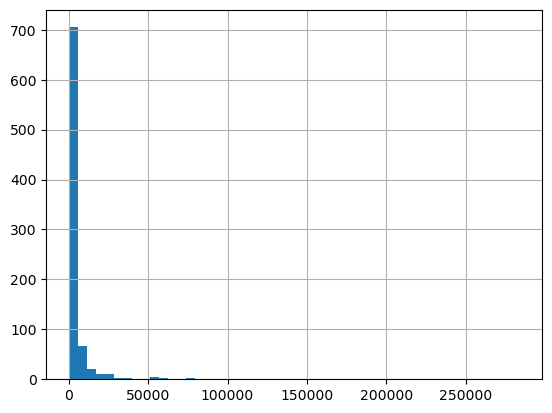

count       831.000000
mean       4634.024886
std       14262.973631
min          62.830000
25%         635.760000
50%        1773.190000
75%        3628.890000
max      284164.830000
Name: price_breakdown_baseprice_price, dtype: float64
Keeping prices between: -3854 and 8119
Rows before: 831
Rows after: 748


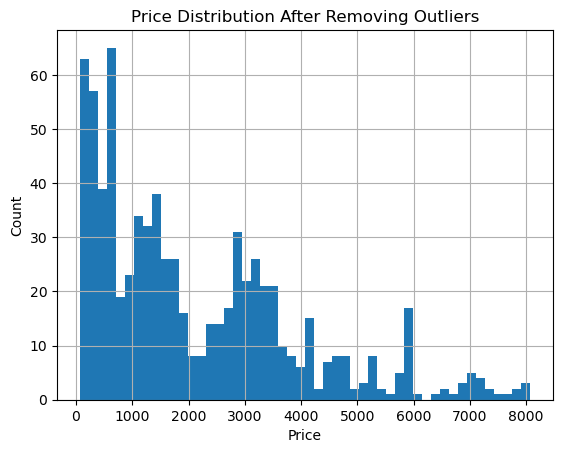

In [11]:
import matplotlib.pyplot as plt
print(df['price_breakdown_baseprice_price'].describe())
df['price_breakdown_baseprice_price'].hist(bins=50)
plt.show()

# Check the actual numbers first
print(df['price_breakdown_baseprice_price'].describe())

# Remove outliers using IQR method
Q1 = df['price_breakdown_baseprice_price'].quantile(0.25)
Q3 = df['price_breakdown_baseprice_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Keeping prices between: {lower:.0f} and {upper:.0f}")
print(f"Rows before: {len(df)}")
df_clean = df[(df['price_breakdown_baseprice_price'] >= lower) & 
              (df['price_breakdown_baseprice_price'] <= upper)]
print(f"Rows after: {len(df_clean)}")
# Output the URL of the row with min price_breakdown_baseprice_price

# Check new distribution
df_clean['price_breakdown_baseprice_price'].hist(bins=50)
plt.title('Price Distribution After Removing Outliers')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

In [12]:
# ──  Define X and Y ────────────────────────────────────────────────
Y = df_clean['price_breakdown_baseprice_price']
X = df_clean.drop(columns=['price_breakdown_baseprice_price'])

# ──  Train/Test Split ──────────────────────────────────────────────
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# print(X_train.isna().sum().sort_values(ascending=False))

# ──  Linear Regression ────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, Y_train)
# Evaluate on train and test sets
Y_pred_train = lr.predict(X_train)
evaluate("Linear Regression (Train)", Y_train, Y_pred_train)
Y_pred_test = lr.predict(X_test)
evaluate("Linear Regression (Test)", Y_test, Y_pred_test)


  Linear Regression (Train)
  MAE  : 979.09  (off by $979.09 on average)
  RMSE : 1337.56
  NRMSE: 0.1706
  R²   : 0.3925  (39.2% variance explained)

  Linear Regression (Test)
  MAE  : 1207.73  (off by $1207.73 on average)
  RMSE : 1726.34
  NRMSE: 0.2155
  R²   : 0.2864  (28.6% variance explained)


In [13]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

# Evaluate on train and test sets
Y_pred_train = rf.predict(X_train)
evaluate("Random Forest Train", Y_train, Y_pred_train)
Y_pred_test = rf.predict(X_test)
evaluate("Random Forest Test", Y_test, Y_pred_test)

# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, Y_train)

Y_pred_train = gb.predict(X_train)
evaluate("Gradient Boosting Train", Y_train, Y_pred_train)
Y_pred_test = gb.predict(X_test)
evaluate("Gradient Boosting Test", Y_test, Y_pred_test)



  Random Forest Train
  MAE  : 277.05  (off by $277.05 on average)
  RMSE : 418.06
  NRMSE: 0.0533
  R²   : 0.9407  (94.1% variance explained)

  Random Forest Test
  MAE  : 858.24  (off by $858.24 on average)
  RMSE : 1375.89
  NRMSE: 0.1717
  R²   : 0.5467  (54.7% variance explained)

  Gradient Boosting Train
  MAE  : 501.10  (off by $501.10 on average)
  RMSE : 752.35
  NRMSE: 0.0960
  R²   : 0.8078  (80.8% variance explained)

  Gradient Boosting Test
  MAE  : 909.45  (off by $909.45 on average)
  RMSE : 1424.25
  NRMSE: 0.1778
  R²   : 0.5143  (51.4% variance explained)


#### Saving Final Models

In [14]:
import joblib
import os

os.makedirs('Models', exist_ok=True)

joblib. dump(rf,  'Models/random_forest.pkl')
joblib.dump(lr,  'Models/linear_regression.pkl')

# Also save the feature columns for Streamlit later
import json
with open('Models/feature_columns.json', 'w') as f:
    json.dump(X_train.columns.tolist(), f)

print("✅ Models saved!")

✅ Models saved!
